# Univariate Data Analysis and Data Quality Assessment

## Introduction

In this session, we will focus on performing a structured **univariate analysis** of both numerical and categorical variables within a dataset. Univariate analysis is a fundamental step in Exploratory Data Analysis (EDA), allowing us to understand the individual behavior of each feature before proceeding to multivariate analysis or predictive modeling.

The main objective of this notebook is to explore how each variable behaves independently, identify potential data quality issues, and make informed decisions regarding transformations or preprocessing steps.

---

Topics Covered

Throughout this session, we will:

- Examine the distribution of numerical variables using descriptive statistics and visualizations.
- Identify skewness and evaluate whether transformations (e.g., log transformation) are necessary.
- Detect and interpret outliers using statistical criteria such as the IQR method.
- Analyze categorical variables through frequency tables and bar charts.
- Identify rare levels and assess category imbalance.
- Evaluate missing values and discuss appropriate handling strategies.
- Assess and classify the overall data quality of each attribute.
- Update the dataset report with a dedicated section on **"Data Quality and Distributions."**

---

In [1]:
#read Ames housing data
import pandas as pd
ames = pd.read_csv('./data/raw/AmesHousing.csv')
ames.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## Descriptive Statistics for Numerical Variables

We begin our univariate analysis of the **Ames Housing dataset** by examining descriptive statistics for numerical variables.

Descriptive statistics provide a quantitative summary of a variable’s central tendency, dispersion, and distribution shape. Before visualizing the data, these metrics allow us to detect potential irregularities such as skewness, extreme values, or limited variability.

### Why This Step Is Important

For datasets like Ames Housing — which contains several continuous and discrete numerical features (e.g., `SalePrice`, `LotArea`, `GrLivArea`, `OverallQual`) — understanding the statistical profile of each variable helps us:

- Identify asymmetry in the distribution
- Detect unusually large or small values
- Evaluate variability and scale differences
- Compare mean and median to assess skewness
- Determine whether transformation may be necessary

---

### Key Descriptive Measures

For each numerical variable, we will compute:

- **Count** – Number of non-missing observations
- **Mean** – Arithmetic average
- **Median (50%)** – Middle value
- **Standard Deviation (std)** – Measure of dispersion
- **Minimum and Maximum** – Range of values
- **Quartiles (Q1 and Q3)** – Distribution spread
- **Interquartile Range (IQR)** – Q3 − Q1
- **Skewness** – Degree of asymmetry
- **Kurtosis** – Tail heaviness

---

### Interpreting the Results

When analyzing the output, we will focus on:

- **Mean vs Median**
  - If mean > median → positive skew (right tail)
  - If mean < median → negative skew (left tail)

- **Standard Deviation**
  - High values indicate greater variability
  - May suggest heterogeneity in housing characteristics

- **Range and IQR**
  - Large spread may indicate potential outliers

- **Skewness**
  - Values > 1 or < -1 indicate strong asymmetry

- **Kurtosis**
  - High kurtosis suggests heavy tails and extreme values

---

In [2]:
# make descriptive analysis for Lot Area
ames['Lot Area'].describe()

count      2930.000000
mean      10147.921843
std        7880.017759
min        1300.000000
25%        7440.250000
50%        9436.500000
75%       11555.250000
max      215245.000000
Name: Lot Area, dtype: float64

In [8]:
#compare standard deviation with mean
ames['Lot Area'].std()/ames['Lot Area'].mean()

np.float64(0.7765154167867433)

In [9]:
#this means high variability in Lot Area, which may indicate the presence of outliers or a wide range of lot sizes in the dataset.

### Interpreting Standard Deviation and Its Relationship with the Mean

The **standard deviation** measures how dispersed the values of a variable are around its mean. While the mean provides information about the central location of the data, the standard deviation tells us how tightly or loosely the data points cluster around that center.

---

### 1. Understanding Standard Deviation

- A **small standard deviation** indicates that most values are close to the mean.
- A **large standard deviation** indicates that the values are more spread out.
- A value of zero would mean that all observations are identical.

In real-world datasets such as housing prices, a high standard deviation often reflects natural variability — for example, differences between small suburban houses and large luxury properties.

---

### 2. Comparing Standard Deviation with the Mean

To properly interpret dispersion, it is important to compare the standard deviation to the mean. This comparison helps determine whether the variability is small or large relative to the magnitude of the variable.

#### Key interpretations:

- **Standard deviation much smaller than the mean**
  - Indicates relatively low variability.
  - Values are concentrated around the average.

- **Standard deviation close to the mean**
  - Indicates moderate to high variability.
  - The data may be widely distributed.

- **Standard deviation larger than the mean**
  - Suggests very high dispersion.
  - May indicate skewness or the presence of extreme values (outliers).

---

### 3. Coefficient of Variation (Optional but Recommended)

A useful way to standardize this comparison is the **Coefficient of Variation (CV)**:

CV = Standard Deviation/Mean

- CV < 0.3 → Low relative variability
- 0.3 ≤ CV < 0.7 → Moderate variability
- CV ≥ 0.7 → High variability

This metric is especially helpful when comparing variables with different scales (e.g., `LotArea` vs. `OverallQual`).

---

In [10]:
#analyse range and IQR
lot_area_range = ames['Lot Area'].max() - ames['Lot Area'].min()
lot_area_iqr = ames['Lot Area'].quantile(0.75) - ames['Lot Area'].quantile(0.25)
print(f'Range of Lot Area: {lot_area_range}')
print(f'IQR of Lot Area: {lot_area_iqr}')

Range of Lot Area: 213945
IQR of Lot Area: 4115.0


In [11]:
#this means that the range of 'Lot Area' is quite large, indicating a wide spread of lot sizes. The IQR provides a measure of the middle 50% of the data, and if the range is significantly larger than the IQR, it may suggest the presence of outliers or extreme values in the dataset.

In [19]:
#print head of outliers in Lot Area using lot_area_iqr
lot_area_q1 = ames['Lot Area'].quantile(0.25)
lot_area_q3 = ames['Lot Area'].quantile(0.75)
lot_area_iqr = lot_area_q3 - lot_area_q1
lower_bound = lot_area_q1 - 1.5 * lot_area_iqr
upper_bound = lot_area_q3 + 1.5 * lot_area_iqr
outliers_lower = ames[ames['Lot Area'] < lower_bound]
print(len(outliers_lower))

0


In [20]:
outliers_higher = ames[ames['Lot Area'] > upper_bound]
print(len(outliers_higher))

127


### Understanding the Interquartile Range (IQR) and Its Importance

The **Interquartile Range (IQR)** is a measure of statistical dispersion that represents the spread of the middle 50% of a dataset. It is calculated as the difference between the third quartile (Q3) and the first quartile (Q1):

IQR = Q3 - Q1

Where:

- **Q1 (25th percentile)**: 25% of the data lies below this value.
- **Q3 (75th percentile)**: 75% of the data lies below this value.
- The IQR captures the central half of the distribution.

---

### 1. What the IQR Tells Us

Unlike the range (max − min), which is highly sensitive to extreme values, the IQR focuses only on the central portion of the data. This makes it a **robust measure of variability**.

A:

- **Small IQR** indicates that the central values are tightly clustered.
- **Large IQR** suggests greater dispersion among the middle 50% of observations.

In housing datasets, for example, a large IQR in `SalePrice` would indicate substantial variability among typical properties — even before considering luxury outliers.

---

### 2. Why the IQR Is Important

#### A. Robustness to Outliers
The IQR is not affected by extreme values because it ignores the lowest 25% and highest 25% of observations. This makes it more reliable than standard deviation in skewed distributions.

#### B. Outlier Detection
The IQR is commonly used to identify outliers using the following rule:

Lower bound:
\[
Q1 - 1.5 * IQR
\]

Upper bound:
\[
Q3 + 1.5 * IQR
\]

Any value outside these bounds is considered a potential outlier.

This rule is the basis of boxplots and is widely used in exploratory data analysis.

#### C. Distribution Assessment
Comparing the IQR with the full range helps assess whether extreme values are stretching the distribution.

- Large range but moderate IQR → likely presence of extreme values.
- Large IQR → true variability in central observations.

---

Text(0.5, 0, 'Lot Area')

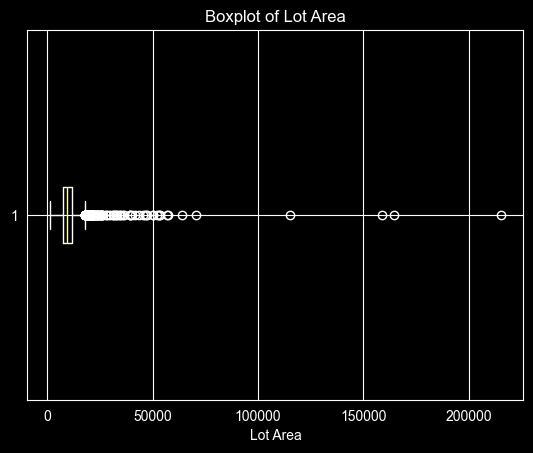

In [18]:
#boxplot of Lot Area
plt.boxplot(ames['Lot Area'], vert=False)
plt.title('Boxplot of Lot Area')
plt.xlabel('Lot Area')

In [3]:
if ames['Lot Area'].mean() > ames['Lot Area'].median():
    print('The distribution of Lot Area is positively skewed.')
elif ames['Lot Area'].mean() < ames['Lot Area'].median():
    print('The distribution of Lot Area is negatively skewed.')
else:
    print('The distribution of Lot Area is symmetric.')

The distribution of Lot Area is positively skewed.


![image.png](attachment:e8fadeab-9a8e-4890-ac50-97b8bdd09cf1.png)

In [4]:
ames['Lot Area'].skew()

np.float64(12.820898171092681)

Text(0, 0.5, 'Frequency')

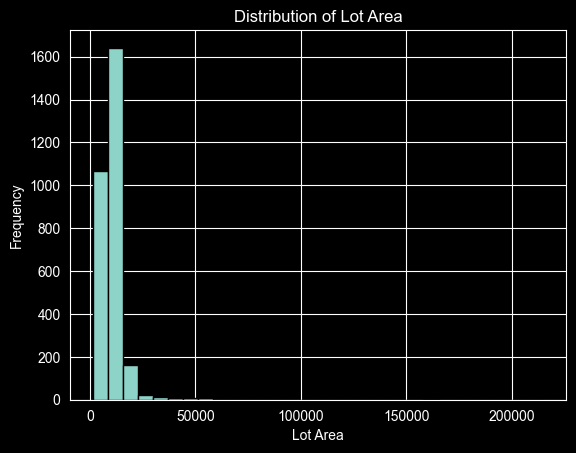

In [5]:
#print distribution of Lot Area
import matplotlib.pyplot as plt
plt.hist(ames['Lot Area'], bins=30, edgecolor='k')
plt.title('Distribution of Lot Area')
plt.xlabel('Lot Area')
plt.ylabel('Frequency')

In [6]:
#what this means?
# The histogram of 'Lot Area' shows the frequency distribution of lot sizes in the Ames Housing dataset. The shape of the histogram can indicate whether the data is skewed, has outliers, or follows a normal distribution. If the histogram is right-skewed (long tail on the right), it suggests that there are some properties with very large lot areas compared to the majority.

### Understanding Skewness

**Skewness** measures the degree of asymmetry of a distribution around its mean.

- Skewness = 0 → perfectly symmetric distribution
- Skewness > 0 → right-skewed (long right tail)
- Skewness < 0 → left-skewed (long left tail)

---

### 1. General Interpretation Scale

Although there is no strict universal rule, a commonly used guideline is:

- |Skewness| < 0.5 → Approximately symmetric
- 0.5 ≤ |Skewness| < 1 → Moderately skewed
- |Skewness| ≥ 1 → Highly skewed

---

### 2. Interpreting a Skewness of 12.82

A skewness value of:

Skewness = 12.82


is **extremely high** and indicates a very strong positive (right) skew.

This means:

- The distribution has a **very long right tail**.
- Most observations are concentrated at lower values.
- A small number of very large values are stretching the distribution.
- The mean is likely much larger than the median.
- Extreme values heavily influence the average.

In practical terms (e.g., housing data), this could indicate:
- A small number of luxury properties with exceptionally high prices.
- Strong presence of extreme outliers.
- A variable with exponential-type growth behavior.

---

In [7]:
ames['Lot Area'].kurt()

np.float64(265.0236706029328)

In [7]:
#this means high kurtosis indicates that the distribution of 'Lot Area' has heavy tails and a sharp peak, suggesting that there are more extreme values (outliers) than a normal distribution would predict. This is consistent with the presence of outliers we identified earlier using the IQR method.

### Understanding Kurtosis

**Kurtosis** measures the shape of a distribution, specifically the heaviness of its tails and the concentration of extreme values.

While skewness measures asymmetry, kurtosis measures how prone a distribution is to producing extreme outliers.

In most statistical libraries (including pandas and scipy), kurtosis is reported as **excess kurtosis**, where:

- Kurtosis = 0 → Normal distribution
- Kurtosis > 0 → Heavy tails (leptokurtic)
- Kurtosis < 0 → Light tails (platykurtic)

---

### 1. General Interpretation Scale

Although interpretation depends on context, a rough guideline is:

- Kurtosis ≈ 0 → Similar to normal distribution
- 0 < Kurtosis < 3 → Moderately heavy tails
- Kurtosis ≥ 3 → Heavy tails and more extreme values
- Very large values → Strong presence of extreme outliers

---

### 2. Interpreting the value

A kurtosis value of:

Kurtosis = 265.02


is **extremely high** and indicates:

- Extremely heavy tails
- A very high concentration of extreme values
- Strong deviation from normality
- Likely presence of severe outliers

This suggests that the distribution produces far more extreme observations than a normal distribution would.

In practical terms (e.g., housing data), this could mean:

- A small number of extremely high property values
- Strong data imbalance
- Potential data entry errors
- A variable with exponential growth behavior

---

### 3. Why This Matters

Such an extreme kurtosis value has important implications:

#### A. Outliers Are Dominating the Distribution
The variable likely contains extreme observations that heavily influence statistical measures.

#### B. Standard Deviation Becomes Less Informative
Dispersion metrics become inflated.

#### C. Modeling Assumptions May Be Violated
Many statistical models assume approximately normal residuals. Extremely high kurtosis suggests strong non-normality.

---

### Overall Data Quality Assessment

From a **data validity perspective**, `LotArea` is likely a reliable and meaningful feature — variability in lot sizes is expected and contextually reasonable.

However, from a **statistical modeling perspective**, the variable presents challenges:

- High dispersion
- Strong positive skewness
- Heavy tails
- Presence of extreme values

**Moderate Quality (Statistically Challenging but Valid)**

## Univariate Analysis of Categorical Variables

In this section, we shift our focus from numerical features to **categorical variables**. While numerical variables describe measurable quantities (e.g., area, price, number of rooms), categorical variables represent qualitative characteristics such as neighborhood, building type, condition, or quality ratings.

Understanding categorical variables is equally important in exploratory data analysis because their distribution directly impacts data quality, model stability, and interpretability.

---

### Why Analyze Categorical Variables?

Categorical features can present specific challenges that are not visible in numerical analysis, such as:

- Imbalanced categories
- Rare levels
- High cardinality (too many unique categories)
- Inconsistent or noisy labels
- Missing values treated as categories

These issues can strongly influence predictive models, especially when encoding techniques are applied.

---

### Main Objectives of This Section

During the univariate analysis of categorical variables, we will:

- Compute frequency tables (absolute and relative frequencies).
- Visualize category distributions using bar charts.
- Identify rare categories and evaluate their impact.
- Detect class imbalance.
- Assess missing values and decide whether they represent true absence or data quality issues.
- Evaluate overall attribute quality and determine if grouping or encoding adjustments are needed.

---

In [22]:
ames.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [28]:
#using MS Zoning as an example of categorical variable
ames['MS Zoning'].value_counts()

MS Zoning
RL         2273
RM          462
FV          139
RH           27
C (all)      25
I (all)       2
A (agr)       2
Name: count, dtype: int64

In [29]:
#show percentage of each category
ames['MS Zoning'].value_counts(normalize=True) * 100

MS Zoning
RL         77.576792
RM         15.767918
FV          4.744027
RH          0.921502
C (all)     0.853242
I (all)     0.068259
A (agr)     0.068259
Name: proportion, dtype: float64

In [25]:
#identify rare categories in MS Zoning
rare_threshold = 0.05  # Define a threshold for rarity (e.g., 5%)
rare_categories = ames['MS Zoning'].value_counts(normalize=True) < rare_threshold
print(ames['MS Zoning'].value_counts()[rare_categories])

MS Zoning
FV         139
RH          27
C (all)     25
I (all)      2
A (agr)      2
Name: count, dtype: int64


### Absolute and Relative Frequencies

The first step in the univariate analysis of a categorical variable is to examine its **distribution of categories**.

This is done by computing:

- **Absolute Frequency** → The count of observations in each category.
- **Relative Frequency** → The percentage of observations in each category.

#### Why This Matters

Analyzing frequencies allows us to:

- Understand how the data is distributed.
- Detect class imbalance.
- Identify dominant and minority categories.
- Evaluate whether the variable provides meaningful variability.

For example, if one category represents 90% of the observations, the variable may carry limited discriminatory power.

Absolute frequencies help us assess sample size reliability, while relative frequencies help us understand proportional importance.

---

### Identifying Rare Levels

After computing category frequencies, the next step is to detect **rare levels**.

Rare levels are categories that appear very infrequently in the dataset.

#### Common Criteria for Rare Categories:

- Categories representing **less than 5%** of total observations.
- Categories with **fewer than 10 observations**.
- Categories that appear only once or twice.

These thresholds are heuristic and may vary depending on dataset size and modeling goals.

---

### Why Rare Levels Matter

Rare categories can create several issues:

- Increase model complexity after encoding.
- Lead to unstable parameter estimates.
- Increase the risk of overfitting.
- Reduce generalization performance.
- Produce sparse feature matrices.

---

### Possible Decisions

Once rare levels are identified, we must decide how to handle them:

#### 1. Group as “Other”
Combine all rare categories into a single category (e.g., "Other").

- Reduces sparsity.
- Improves model stability.
- Preserves information while simplifying structure.

#### 2. Remove the Variable
If the variable contains too many rare levels and little predictive value, it may be excluded.

#### 3. Keep Them (If Contextually Important)
Some rare categories may represent meaningful or high-value cases (e.g., luxury neighborhoods). In such cases, removal may cause information loss.

---

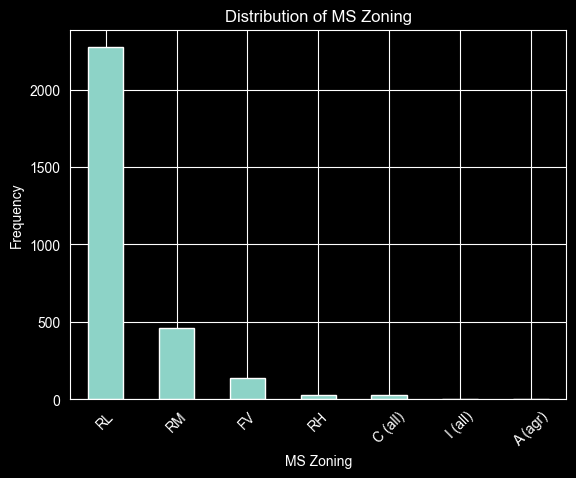

In [26]:
#plot bar chart of MS Zoning for check imbalance
import matplotlib.pyplot as plt
ames['MS Zoning'].value_counts().plot(kind='bar')
plt.title('Distribution of MS Zoning')
plt.xlabel('MS Zoning')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

In [27]:
#avaliar cardinality of MS Zoning
cardinality = ames['MS Zoning'].nunique()
print(f'Cardinality of MS Zoning: {cardinality}')

Cardinality of MS Zoning: 7


### Evaluating Cardinality

**Cardinality** refers to the number of unique categories (levels) that a categorical variable contains.

---

### Why Is High Cardinality a Problem?

When a categorical variable has many unique levels, it can create several modeling challenges:

#### 1. Risk of Overfitting

If we apply techniques like one-hot encoding to a high-cardinality variable:

- The model creates one feature per category.
- Some categories may appear only a few times.
- The model may "memorize" these rare patterns instead of learning generalizable relationships.

This leads to overfitting — strong performance on training data but poor generalization to new data.

---

#### 2. Sparse Data Representation

High cardinality often produces many sparse columns after encoding, which:

- Increases model complexity
- Slows computation
- Adds noise
- Reduces interpretability

---

### When Should We Be Concerned?

There is no strict rule, but typically:

- < 10 categories → low cardinality (safe)
- 10–30 categories → moderate (needs evaluation)
- > 50 categories → high (requires attention)
- Near-unique values → very high (often useless as predictors)

---

### Possible Solutions

When cardinality is high, we may consider:

#### 1. Target Encoding
Replace each category with the average target value for that category.

Example:
Neighborhood → mean SalePrice per neighborhood

Pros:
- Reduces dimensionality
- Captures predictive signal

Cons:
- Must be applied carefully to avoid data leakage

---

#### 2. Grouping Rare Categories

Combine infrequent categories into a single group such as:

"Other"

This:
- Reduces sparsity
- Improves model stability
- Decreases overfitting risk

---

#### 3. Removal

If the variable:
- Has almost unique values (like IDs),
- Adds no meaningful predictive information,
- Or introduces excessive noise,

It may be best to remove it from the dataset.

---

### Practical Interpretation

When evaluating a categorical variable, ask:

- How many unique categories does it have?
- Are some categories extremely rare?
- Does this variable represent meaningful structure or just identifiers?

High cardinality does not automatically mean low quality — but it requires careful handling to avoid overfitting and unstable models.

### Attribute Quality Assessment

- RL → 77.58%
- RM → 15.77%
- FV → 4.74%
- RH → 0.92%
- C (all) → 0.85%
- I (all) → 0.07%
- A (agr) → 0.07%


With 7 categories, the variable has **low cardinality**.

Although the number of categories is small, the distribution is highly imbalanced:

- One category (RL) dominates with ~78% of observations.
- RM represents ~16%.
- All remaining categories individually represent less than 5%.
- Three categories have extremely low frequency (<1%).

This suggests strong imbalance.
**Moderate Quality**

The variable has:
- Low cardinality (positive)
- Strong imbalance (moderate concern)
- Several rare levels (requires consideration)

It is structurally valid and interpretable but may require grouping of very rare categories to improve statistical stability.

This attribute is usable and meaningful but presents imbalance issues. With appropriate handling of rare levels, it can be safely incorporated into predictive modeling.